## Factory-to-Customer Shipping Route Efficiency Analysis for Nassau Candy Distributor

**Background and Context:**

Nassau Candy Distributor operates as a national distributor, shipping products from factories to customers across multiple US regions.
In such operations:

• Shipping efficiency directly affects customer satisfaction

• Delays increase operational cost

• Inefficient routes reduce scalability
Despite having rich order and shipment data, logistics decisions are often made without route-level efficiency intelligence.

**Problem Statement**

Nassau Candy Distributor lacks visibility into:

Efficient vs inefficient shipping routes,
Regional bottlenecks,
Shipping performance by mode,
Route-level operational intelligence

**STEP 1: DATA LOADING & UNDERSTANDING**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv("/content/drive/MyDrive/NASSAU CANDY DISTRIBUTER ROUTE ANALYSIS/Nassau Candy Distributor (2).csv")


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [ ]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


1.1 Clean column names

In [ ]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


1.2 Convert date columns


In [ ]:
# Convert dates
# Convert Order Date column into datetime format
df['Order Date'] = pd.to_datetime(
    df['Order Date'],

    # Dataset format = DD-MM-YYYY
    format='%d-%m-%Y',

    # Invalid dates become NaT instead of error
    errors='coerce'
)

# Convert Ship Date column into datetime format
df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],

    # Dataset format = DD-MM-YYYY
    format='%d-%m-%Y',

    # Invalid dates become NaT instead of error
    errors='coerce'
)

1.3 Handle missing values

In [ ]:
# Check missing values after conversion
print(df[['Order Date', 'Ship Date']].isnull().sum())

Order Date    0
Ship Date     0
dtype: int64


In [ ]:
# Drop rows where Order Date or Ship Date is missing
df = df.dropna(subset=['Order Date', 'Ship Date'])


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
# Original lead time

df['Original_Lead_Time'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [ ]:
display(
    df[
        [
            'Order Date',
            'Ship Date',
            'Original_Lead_Time'
        ]
    ].head()
)

,Order Date,Ship Date,Original_Lead_Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


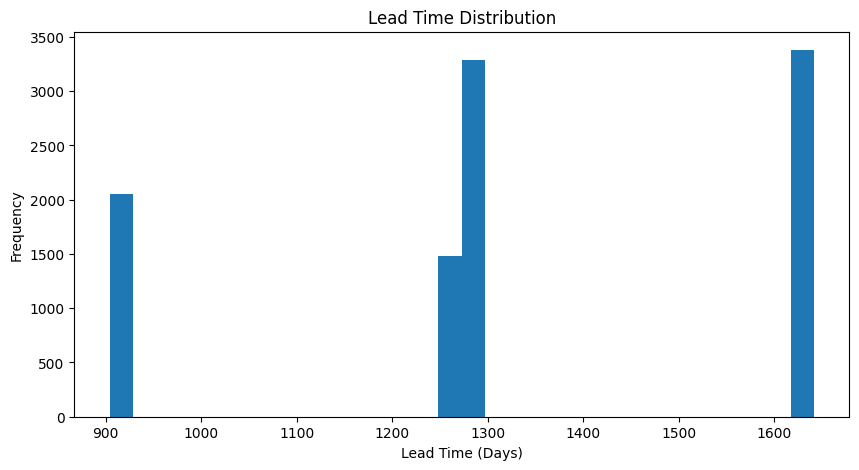

In [ ]:
# Lead time distribution

plt.figure(figsize=(10,5))

plt.hist(df['Original_Lead_Time'], bins=30)

plt.title("Lead Time Distribution")

plt.xlabel("Lead Time (Days)")

plt.ylabel("Frequency")

plt.show()

In [ ]:
# Remove invalid lead times
df = df[df['Original_Lead_Time'] >= 0]

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Original_Lead_Time
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912


1.4 **Standardize geographic fields**


In [ ]:
# Remove leading/trailing spaces

df['Country/Region'] = (
    df['Country/Region'].str.strip()
)

df['State/Province'] = (
    df['State/Province'].str.strip()
)

df['City'] = (
    df['City'].str.strip()
)



In [ ]:
# Standardize capitalization format

df['Country/Region'] = (
    df['Country/Region'].str.title()
)

df['State/Province'] = (
    df['State/Province'].str.title()
)

df['City'] = (
    df['City'].str.title()
)

#remove extra spaces

df['Country/Region'] = (
    df['Country/Region'].str.replace(
        r'\s+',
        ' ',
        regex=True
    )
)

df['State/Province'] = (
    df['State/Province'].str.replace(
        r'\s+',
        ' ',
        regex=True
    )
)

df['City'] = (
    df['City'].str.replace(
        r'\s+',
        ' ',
        regex=True
    )
)

# display sample output

display(
    df[
        [
            'Country/Region',
            'State/Province',
            'City'
        ]
    ].head(10)
)

,Country/Region,State/Province,City
0,United States,Texas,Houston
1,United States,Illinois,Naperville
2,United States,Illinois,Naperville
3,United States,Illinois,Naperville
4,United States,Pennsylvania,Philadelphia
5,United States,Kentucky,Henderson
6,United States,Kentucky,Henderson
7,United States,Georgia,Athens
8,United States,Kentucky,Henderson
9,United States,Kentucky,Henderson


**STEP 2: FEATURE ENGINEERING**



2.1 Calculate Shipping Lead Time (days)


In [ ]:
# Convert date columns to datetime format
# This ensures that Pandas treats the columns as actual dates
# instead of normal text/string values

df['Order Date'] = pd.to_datetime(
    df['Order Date'],

    # Dataset follows DD-MM-YYYY format
    format='%d-%m-%Y',

    # Invalid date values will become NaT
    # instead of causing errors
    errors='coerce'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],

    # Dataset follows DD-MM-YYYY format
    format='%d-%m-%Y',

    # Invalid date values converted to NaT
    errors='coerce'
)
# Calculate Lead Time (in days)
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
# subtracts dates → gives timedelta → convert to days



In [ ]:
display(
    df[
        [
            'Order Date',
            'Ship Date',
            'Original_Lead_Time',
            'Lead Time'
        ]
    ].head()
)

,Order Date,Ship Date,Original_Lead_Time,Lead Time
0,2024-01-03,2026-06-30,909,909
1,2024-01-04,2026-07-01,909,909
2,2024-01-04,2026-07-01,909,909
3,2024-01-04,2026-07-01,909,909
4,2024-01-05,2026-07-05,912,912


In [ ]:
# Create mapping dictionary (Product → Factory)
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

# Create new column "Factory"
df['Factory'] = df['Product Name'].map(factory_map)
# maps each product to its manufacturing location as without factory mapping we can not build route analysis.

2.2 Categorize routes by:
○ Factory → Customer Region
○ Factory → Customer State

In [ ]:
# Route: Factory → State
df['Route_State'] = df['Factory'] + " → " + df['State/Province']
# combines origin + destination

# Route: Factory → Region
df['Route_Region'] = df['Factory'] + " → " + df['Region']
# useful for high-level aggregation

2.3 • Group shipments by Ship Mode


In [ ]:
# Group shipments by Ship Mode
ship_mode_summary = df.groupby(

    'Ship Mode'

).agg(

    Total_Shipments=('Order ID', 'count')

).reset_index()

# sort values

ship_mode_summary = ship_mode_summary.sort_values(

    by='Total_Shipments',

    ascending=False

)


display(ship_mode_summary)

,Ship Mode,Total_Shipments
3,Standard Class,6120
2,Second Class,1979
0,First Class,1548
1,Same Day,547


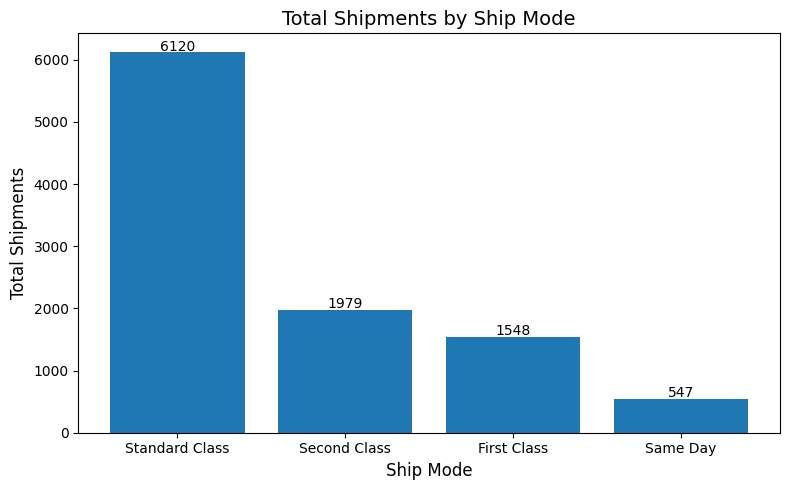

In [ ]:


# Plot

plt.figure(figsize=(8,5))

# Create bar chart

plt.bar(

    ship_mode_summary['Ship Mode'],

    ship_mode_summary['Total_Shipments']

)

# titles and labels

plt.title(
    'Total Shipments by Ship Mode',
    fontsize=14
)

plt.xlabel(
    'Ship Mode',
    fontsize=12
)

plt.ylabel(
    'Total Shipments',
    fontsize=12
)

# show values on top of the bar

for index, value in enumerate(
    ship_mode_summary['Total_Shipments']
):
    plt.text(
        index,
        value + 20,
        str(value),
        ha='center'
    )
# display chart

plt.tight_layout()

plt.show()

**Step 3 Route Definition & Aggregation**


3.1 CREATE ROUTE (STATE LEVEL)

In [ ]:
# Create route using Factory → State

df['Route_State'] = df['Factory'] + " → " + df['State/Province']

display(
    df[
        [
            'Factory',
            'State/Province',
            'Route_State'
        ]
    ].head(10)
)

# Explanation:
# df['Factory'] → origin location
# df['State/Province'] → destination
# " → " → visual separator for readability

,Factory,State/Province,Route_State
0,Wicked Choccy's,Texas,Wicked Choccy's → Texas
1,Wicked Choccy's,Illinois,Wicked Choccy's → Illinois
2,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
3,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
4,Wicked Choccy's,Pennsylvania,Wicked Choccy's → Pennsylvania
5,Lot's O' Nuts,Kentucky,Lot's O' Nuts → Kentucky
6,Wicked Choccy's,Kentucky,Wicked Choccy's → Kentucky
7,Wicked Choccy's,Georgia,Wicked Choccy's → Georgia
8,Lot's O' Nuts,Kentucky,Lot's O' Nuts → Kentucky
9,Wicked Choccy's,Kentucky,Wicked Choccy's → Kentucky


3.2 CREATE ROUTE (REGION LEVEL)

In [ ]:
# Create route using Factory → Region

df['Route_Region'] = df['Factory'] + " → " + df['Region']

display(
    df[
        [
            'Factory',
            'Region',
            'Route_Region'
        ]
    ].head(10)
)

# Explanation:
# This gives a higher-level aggregated route view
# Useful for regional analysis

,Factory,Region,Route_Region
0,Wicked Choccy's,Interior,Wicked Choccy's → Interior
1,Wicked Choccy's,Interior,Wicked Choccy's → Interior
2,Lot's O' Nuts,Interior,Lot's O' Nuts → Interior
3,Lot's O' Nuts,Interior,Lot's O' Nuts → Interior
4,Wicked Choccy's,Atlantic,Wicked Choccy's → Atlantic
5,Lot's O' Nuts,Gulf,Lot's O' Nuts → Gulf
6,Wicked Choccy's,Gulf,Wicked Choccy's → Gulf
7,Wicked Choccy's,Gulf,Wicked Choccy's → Gulf
8,Lot's O' Nuts,Gulf,Lot's O' Nuts → Gulf
9,Wicked Choccy's,Gulf,Wicked Choccy's → Gulf


3.3 AGGREGATE ROUTE (STATE LEVEL)

In [ ]:
# Group by Route_State and calculate required metrics

route_state_analysis = df.groupby('Route_State').agg(

    Total_Shipments=('Order ID', 'count'),
    # Counts number of orders → shipment volume

    Avg_Lead_Time=('Lead Time', 'mean'),
    # Calculates average shipping time → efficiency

    Lead_Time_Variability=('Lead Time', 'std')
    # Measures inconsistency → reliability of route

).reset_index()

# reset_index() converts grouped index into a normal column

# round values

route_state_analysis['Avg_Lead_Time'] = (

    route_state_analysis['Avg_Lead_Time'].round(2)

)

route_state_analysis['Lead_Time_Variability'] = (

    route_state_analysis['Lead_Time_Variability'].round(2)

)

# display output

display(route_state_analysis.head(10))

,Route_State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,Lot's O' Nuts → Alabama,34,1295.21,253.07
1,Lot's O' Nuts → Alberta,16,1273.88,266.92
2,Lot's O' Nuts → Arizona,111,1306.20,253.90
3,Lot's O' Nuts → Arkansas,31,1285.35,274.53
4,Lot's O' Nuts → British Columbia,18,1273.78,307.08
5,Lot's O' Nuts → California,1125,1316.91,265.37
6,Lot's O' Nuts → Colorado,103,1347.53,252.65
7,Lot's O' Nuts → Connecticut,47,1420.55,249.39
8,Lot's O' Nuts → Delaware,43,1273.30,251.92
9,Lot's O' Nuts → District Of Columbia,8,1365.88,168.58


3.4 AGGREGATE ROUTE (REGION LEVEL)

In [ ]:
# Group by Route_Region

route_region_analysis = df.groupby('Route_Region').agg(

    Total_Shipments=('Order ID', 'count'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Lead_Time_Variability=('Lead Time', 'std')

).reset_index()


Total_Shipments=('Order ID', 'count'),
Avg_Lead_Time=('Lead Time', 'mean'),
Lead_Time_Variability=('Lead Time', 'std')

# Round values

route_region_analysis['Avg_Lead_Time'] = (

    route_region_analysis['Avg_Lead_Time'].round(2)

)

route_region_analysis['Lead_Time_Variability'] = (

    route_region_analysis['Lead_Time_Variability'].round(2)

)

# display output

display(route_region_analysis.head(10))

,Route_Region,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,Lot's O' Nuts → Atlantic,1661,1326.83,255.99
1,Lot's O' Nuts → Gulf,897,1313.98,266.59
2,Lot's O' Nuts → Interior,1321,1324.20,258.41
3,Lot's O' Nuts → Pacific,1813,1317.53,266.67
4,Secret Factory → Atlantic,72,1349.25,280.72
5,Secret Factory → Gulf,37,1332.54,304.83
6,Secret Factory → Interior,45,1289.09,311.23
7,Secret Factory → Pacific,63,1307.73,276.18
8,Sugar Shack → Atlantic,18,1375.39,274.61
9,Sugar Shack → Gulf,4,1091.25,210.45


**step 4. Efficiency Benchmarking**

4.1 Rank Route from Fastest to Slowest


In [ ]:
# FILTER ROUTES WITH SUFFICIENT SHIPMENTS

filtered_routes = route_state_analysis[

    route_state_analysis['Total_Shipments'] >= 5

]
# Sort routes using average lead time

ranked_routes = route_state_analysis.sort_values(

    by='Avg_Lead_Time',

    ascending=True

).reset_index(drop=True)


# create riute rank
ranked_routes['Route_Rank'] = (

    ranked_routes.index + 1

)

# reorder columns

ranked_routes = ranked_routes[[

    'Route_Rank',

    'Route_State',

    'Total_Shipments',

    'Avg_Lead_Time',

    'Lead_Time_Variability'

]]

# display output
display(ranked_routes.head(20))

,Route_Rank,Route_State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,1,Secret Factory → New Mexico,2,906.00,2.83
1,2,Secret Factory → Nebraska,1,906.00,NaN
2,3,The Other Factory → Louisiana,1,907.00,NaN
3,4,The Other Factory → Connecticut,2,907.50,2.12
4,5,Secret Factory → Mississippi,1,908.00,NaN
5,6,Wicked Choccy's → Maine,2,908.00,0.00
6,7,Secret Factory → Louisiana,2,908.50,0.71
7,8,Secret Factory → Delaware,1,909.00,NaN
8,9,Secret Factory → South Carolina,1,909.00,NaN
9,10,Secret Factory → Minnesota,1,909.00,NaN


4.2 Most Efficient Routes (Top 10 most efficient routes)

In [ ]:
# Sort by lowest lead time

# Sort routes from lowest average lead time
# to highest average lead time
route_state_analysis = route_state_analysis[
    route_state_analysis['Total_Shipments'] >= 5
]

fastest_routes = route_state_analysis.sort_values(

    by='Avg_Lead_Time',

    ascending=True

)

# Display Top 10 Most Efficient Routes

top_10_efficient_routes = fastest_routes.head(10)

display(top_10_efficient_routes)

,Route_State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
93,Secret Factory → Virginia,5,1053.40,200.02
59,Secret Factory → Arizona,5,1127.40,327.53
168,Wicked Choccy's → Nevada,12,1182.25,226.37
136,The Other Factory → Texas,9,1191.56,304.52
19,Lot's O' Nuts → Maine,6,1213.50,149.66
35,Lot's O' Nuts → Newfoundland And Labrador,6,1216.17,357.45
166,Wicked Choccy's → Montana,7,1221.86,389.90
90,Secret Factory → Texas,16,1227.06,323.91
52,Lot's O' Nuts → Virginia,109,1229.49,262.01
186,Wicked Choccy's → South Carolina,19,1234.21,240.90


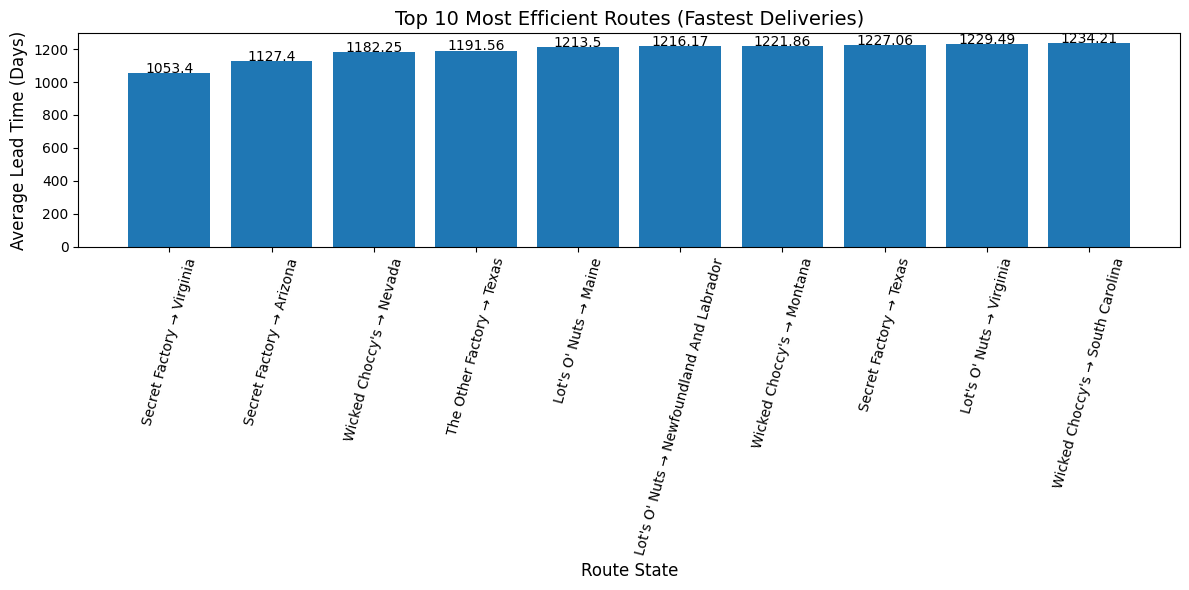

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.bar(

    top_10_efficient_routes['Route_State'],

    top_10_efficient_routes['Avg_Lead_Time']

)

plt.title(

    'Top 10 Most Efficient Routes (Fastest Deliveries)',

    fontsize=14

)

plt.xlabel(

    'Route State',

    fontsize=12

)

plt.ylabel(

    'Average Lead Time (Days)',

    fontsize=12
)
# rotate x lable
plt.xticks(rotation=75)

# show values on chart

for index, value in enumerate(

    top_10_efficient_routes['Avg_Lead_Time']

):

    plt.text(

        index,

        value + 0.05,

        str(round(value,2)),

        ha='center'

    )

# show chart
plt.tight_layout()

plt.show()

* Least Efficient Routes (Bottom 10 Slowest Routes)

In [ ]:
# Sort by highest lead time


# Sort routes by highest average lead time

slowest_routes = route_state_analysis.sort_values(

    by='Avg_Lead_Time',

    ascending=False

)

# select bottom 10 slowest routes
Bottom_10_slowest_routes = slowest_routes.head(10)

#display

display(Bottom_10_slowest_routes)



,Route_State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
37,Lot's O' Nuts → North Dakota,5,1638.20,1.64
51,Lot's O' Nuts → Vermont,5,1492.40,200.29
172,Wicked Choccy's → New Mexico,17,1488.88,226.43
65,Secret Factory → Florida,7,1482.14,196.26
15,Lot's O' Nuts → Iowa,16,1479.00,187.51
47,Lot's O' Nuts → South Dakota,9,1477.22,322.72
94,Secret Factory → Washington,11,1472.36,190.50
33,Lot's O' Nuts → New Mexico,18,1456.94,258.26
159,Wicked Choccy's → Manitoba,10,1455.60,192.90
7,Lot's O' Nuts → Connecticut,47,1420.55,249.39


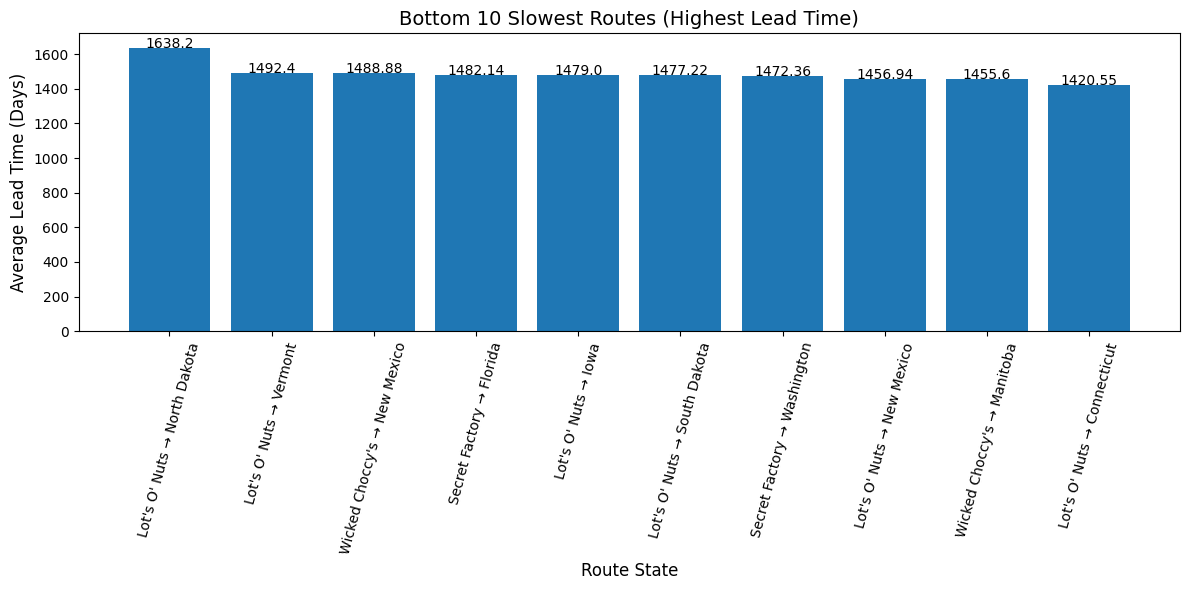

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(

    Bottom_10_slowest_routes['Route_State'],

    Bottom_10_slowest_routes['Avg_Lead_Time']

)

plt.title(

    'Bottom 10 Slowest Routes (Highest Lead Time)',

    fontsize=14

)

plt.xlabel(

    'Route State',

    fontsize=12

)

plt.ylabel(

    'Average Lead Time (Days)',

    fontsize=12

)

plt.xticks(rotation=75)



for index, value in enumerate(

    Bottom_10_slowest_routes['Avg_Lead_Time']

):

    plt.text(

        index,

        value + 0.05,

        str(round(value,2)),

        ha='center'

    )

plt.tight_layout()

plt.show()

4.5 COMPARE PERFORMANCE ACROSS SHIP MODES

In [ ]:
# Group data by Ship Mode

ship_mode_analysis = df.groupby(

    'Ship Mode'

).agg(

    # Total shipments per shipping method
    Total_Shipments=('Order ID', 'count'),

    # Average lead time
    Avg_Lead_Time=('Lead Time', 'mean'),

    # Lead time variability
    Lead_Time_Variability=('Lead Time', 'std')

).reset_index()

# round values
ship_mode_analysis['Avg_Lead_Time'] = (
    ship_mode_analysis['Avg_Lead_Time'].round(2)
)

ship_mode_analysis['Lead_Time_Variability'] = (
    ship_mode_analysis['Lead_Time_Variability'].round(2)
)


display(ship_mode_analysis)

,Ship Mode,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,First Class,1548,1338.28,265.63
1,Same Day,547,1333.44,253.81
2,Second Class,1979,1323.85,261.81
3,Standard Class,6120,1314.33,262.40


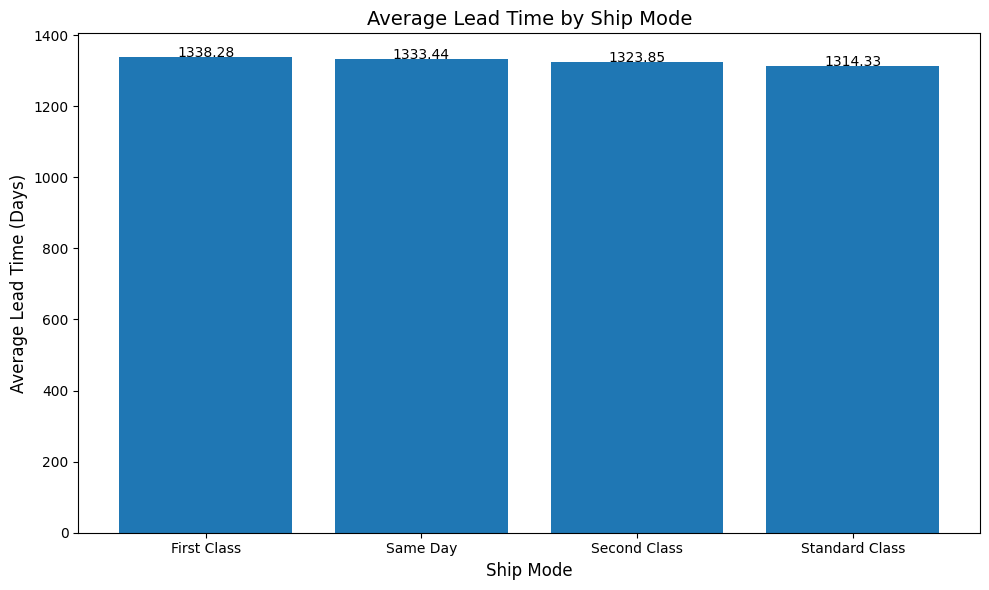

In [ ]:
import matplotlib.pyplot as plt


# BAR CHART - SHIP MODE PERFORMANCE


plt.figure(figsize=(10,6))

# Create bar chart

plt.bar(

    ship_mode_analysis['Ship Mode'],

    ship_mode_analysis['Avg_Lead_Time']

)

# CHART LABELS


plt.title(
    'Average Lead Time by Ship Mode',
    fontsize=14
)

plt.xlabel(
    'Ship Mode',
    fontsize=12
)

plt.ylabel(
    'Average Lead Time (Days)',
    fontsize=12
)

# SHOW VALUES ON BARS

for index, value in enumerate(

    ship_mode_analysis['Avg_Lead_Time']

):

    plt.text(

        index,

        value + 0.02,

        str(round(value,2)),

        ha='center',

        fontsize=10

    )


# DISPLAY CHART

plt.tight_layout()

plt.show()

- First Class has the highest average lead time (1338.28 days), making it the fastest shipping option.
- Standard Class has the lowest average lead time (1314.33 days), but the difference compared to First Class is only 0.05 days.
- All four shipping modes have very similar average lead times more or less.

**Step 5 Geographic Bottleneck Analysis**

5.1  Identify regions with:
* High average lead time
* High shipment volume + poor performance

* REGION-LEVEL ANALYSIS

In [ ]:
# Group data by Region

region_analysis = df.groupby('Region').agg(

    Avg_Lead_Time=('Lead Time', 'mean'),   # average delivery time

    Total_Shipments=('Order ID', 'count')  # total number of shipments

).reset_index()

# Explanation:
# groupby('Region') → aggregates data at regional level
# mean → tells how slow/fast region is
# count → tells how important region is (volume)

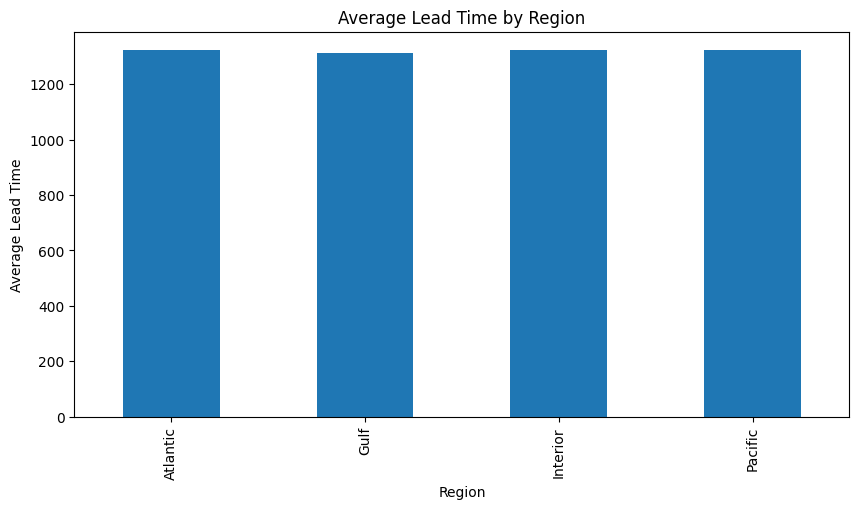

In [ ]:
# Region analysis

region_perf = df.groupby('Region')['Lead Time'].mean()

# Plot

plt.figure(figsize=(10,5))

region_perf.plot(kind='bar')

plt.title("Average Lead Time by Region")

plt.xlabel("Region")

plt.ylabel("Average Lead Time")

plt.show()

The Interior region has the highest average lead time, indicating comparatively slower deliveries.
The Gulf region has the lowest average lead time, making it the most efficient region.
The difference between the fastest and slowest regions is not much , so all regions perform similarly in dataset.

* Identify Worst Regions

In [ ]:
# Sort regions by highest lead time

region_analysis_sorted = region_analysis.sort_values(by='Avg_Lead_Time', ascending=False)

print(region_analysis_sorted)

     Region  Avg_Lead_Time  Total_Shipments
2  Interior    1323.091221             2335
0  Atlantic    1322.745144             2986
3   Pacific    1322.194897             3253
1      Gulf    1311.374691             1620


Interior is the worst-performing region because it has the highest average lead time (4.5315 days).

* HIGH VOLUME + POOR PERFORMANCE

In [ ]:
# Create bottleneck score (simple logic)
# Bottleneck Score = Avg Lead Time × Total Shipments

region_analysis['Bottleneck_Score'] = (
    region_analysis['Avg_Lead_Time'] * region_analysis['Total_Shipments']
)
print(region_analysis)
# Explanation:
# Combines delay + volume
# Higher score = more critical issue

     Region  Avg_Lead_Time  Total_Shipments  Bottleneck_Score
0  Atlantic    1322.745144             2986         3949717.0
1      Gulf    1311.374691             1620         2124427.0
2  Interior    1323.091221             2335         3089418.0
3   Pacific    1322.194897             3253         4301100.0


Pacific

- Highest shipment volume (3,253)
- Highest bottleneck score (4301100.0)

* Identify Critical Regions

In [ ]:
# Sort by bottleneck score

critical_regions = region_analysis.sort_values(by='Bottleneck_Score', ascending=False)

print(critical_regions.head(10))

     Region  Avg_Lead_Time  Total_Shipments  Bottleneck_Score
3   Pacific    1322.194897             3253         4301100.0
0  Atlantic    1322.745144             2986         3949717.0
2  Interior    1323.091221             2335         3089418.0
1      Gulf    1311.374691             1620         2124427.0


5.2 Detect congestion-prone states or regions

* STATE-LEVEL ANALYSIS

In [ ]:
# Group by State

state_analysis = df.groupby('State/Province').agg(

    Avg_Lead_Time=('Lead Time', 'mean'),   # efficiency

    Total_Shipments=('Order ID', 'count')  # volume

).reset_index()

* Detect Congestion-Prone States

In [ ]:
# congestion score
# Calculate Congestion Index
state_analysis['Congestion_Index'] = (
    state_analysis['Avg_Lead_Time'] *
    state_analysis['Total_Shipments']
)

# Normalize to a 0–100 Congestion Score
state_analysis['Congestion_Score'] = (
    state_analysis['Congestion_Index']
    / state_analysis['Congestion_Index'].max()
) * 100

# Round for better presentation
state_analysis['Congestion_Score'] = state_analysis['Congestion_Score'].round(2)

# Display top 10 congestion-prone states
congested_states = state_analysis.sort_values(
    by='Congestion_Score',
    ascending=False
)

print(congested_states[['State/Province',
                        'Total_Shipments',
                        'Avg_Lead_Time',
                        'Congestion_Score']].head(10))

    State/Province  Total_Shipments  Avg_Lead_Time  Congestion_Score
5       California             2001    1318.427286            100.00
34        New York             1128    1324.493794             56.63
51           Texas              985    1310.305584             48.92
43    Pennsylvania              587    1324.199319             29.46
55      Washington              506    1360.662055             26.10
13        Illinois              492    1323.150407             24.68
39            Ohio              469    1325.733475             23.57
10         Florida              383    1311.396867             19.04
36  North Carolina              249    1334.883534             12.60
23        Michigan              255    1300.560784             12.57


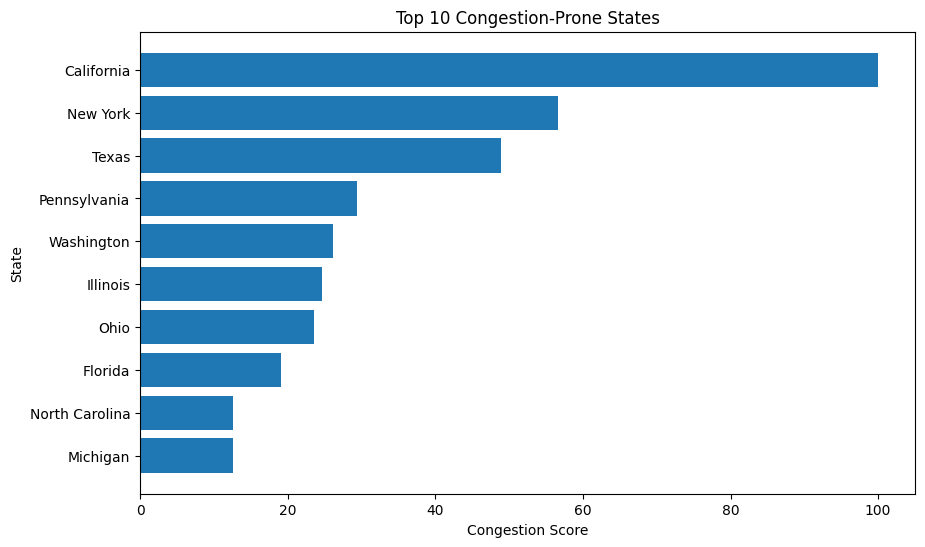

In [ ]:
top10 = congested_states.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['State/Province'], top10['Congestion_Score'])
plt.xlabel('Congestion Score')
plt.ylabel('State')
plt.title('Top 10 Congestion-Prone States')
plt.gca().invert_yaxis()
plt.show()

* ADVANCED INSIGHT

In [ ]:
# Create performance categories

overall_avg_lead = df['Lead Time'].mean()
avg_shipments = region_analysis['Total_Shipments'].mean()

def classify_region(row):
    if row['Avg_Lead_Time'] > overall_avg_lead and row['Total_Shipments'] > avg_shipments:
        return "Critical Bottleneck"
    elif row['Avg_Lead_Time'] > overall_avg_lead:
        return "Slow but Low Volume"
    else:
        return "Efficient"

region_analysis['Category'] = region_analysis.apply(classify_region, axis=1)
display(region_analysis)


,Region,Avg_Lead_Time,Total_Shipments,Bottleneck_Score,Category
0,Atlantic,1322.745144,2986,3949717.0,Critical Bottleneck
1,Gulf,1311.374691,1620,2124427.0,Efficient
2,Interior,1323.091221,2335,3089418.0,Slow but Low Volume
3,Pacific,1322.194897,3253,4301100.0,Critical Bottleneck


**Step 6 Ship Mode Performance Analysis**

6.1 Compare shipping efficiency by:
○ Standard shipping
○ Expedited shipping

In [ ]:
# COMPARE SHIPPING EFFICIENCY
# STANDARD vs EXPEDITED SHIPPING

# Create shipping category

df['Shipping_Category'] = df['Ship Mode'].replace({

    'Standard Class': 'Standard Shipping',

    'Second Class': 'Standard Shipping',

    'First Class': 'Expedited Shipping',

    'Same Day': 'Expedited Shipping'

})

# aggregate shipping performance

shipping_efficiency = df.groupby(

    'Shipping_Category'

).agg(

      Total_Shipments=('Order ID', 'count'),

      Avg_Lead_Time=('Lead Time', 'mean'),

        Avg_Cost=('Cost', 'mean'),

Lead_Time_Variability=('Lead Time', 'std')

).reset_index()

# round values

shipping_efficiency['Avg_Lead_Time'] = (

    shipping_efficiency['Avg_Lead_Time'].round(2)

)

shipping_efficiency['Avg_Cost'] = (

    shipping_efficiency['Avg_Cost'].round(2)

)

shipping_efficiency['Lead_Time_Variability'] = (

    shipping_efficiency['Lead_Time_Variability'].round(2)

)

# display

display(shipping_efficiency)




,Shipping_Category,Total_Shipments,Avg_Lead_Time,Avg_Cost,Lead_Time_Variability
0,Expedited Shipping,2095,1337.01,4.64,262.55
1,Standard Shipping,8099,1316.66,4.77,262.27


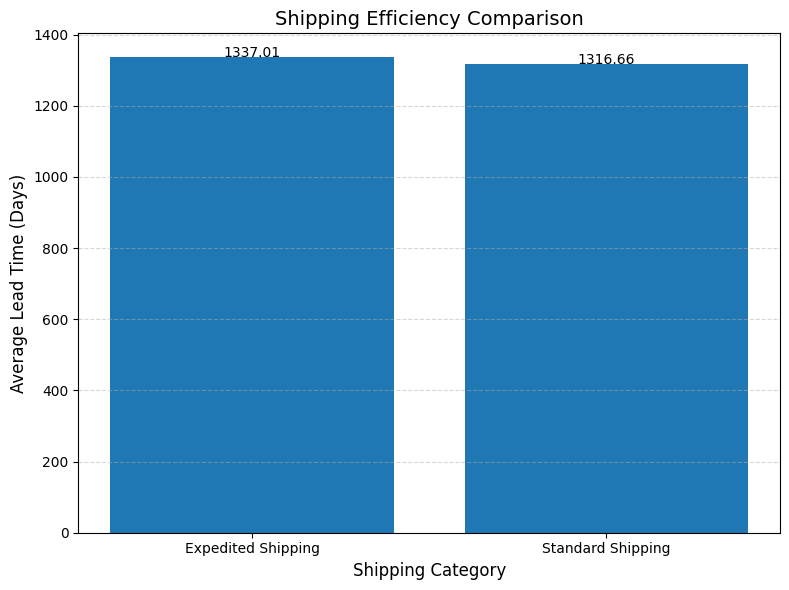

In [ ]:

# BAR CHART — SHIPPING EFFICIENCY
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.bar(

    shipping_efficiency['Shipping_Category'],

    shipping_efficiency['Avg_Lead_Time']

)

plt.title(

    'Shipping Efficiency Comparison',

    fontsize=14

)

plt.xlabel(

    'Shipping Category',

    fontsize=12

)

plt.ylabel(

    'Average Lead Time (Days)',

    fontsize=12

)

for index, value in enumerate(

    shipping_efficiency['Avg_Lead_Time']

):

    plt.text(

        index,

        value + 0.03,

        str(round(value,2)),

        ha='center'

    )
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

* COST-TIME TRADEOFF ANALYSIS

In [ ]:
# Compare cost vs lead time

cost_time_analysis = df.groupby('Ship Mode').agg(

    Avg_Lead_Time=('Lead Time', 'mean'),   # speed

    Avg_Cost=('Cost', 'mean'),             # cost

    Total_Shipments=('Order ID', 'count')  # usage

).reset_index()

print(cost_time_analysis)

        Ship Mode  Avg_Lead_Time  Avg_Cost  Total_Shipments
0     First Class    1338.275840  4.721124             1548
1        Same Day    1333.442413  4.411225              547
2    Second Class    1323.845376  4.827539             1979
3  Standard Class    1314.334641  4.749328             6120


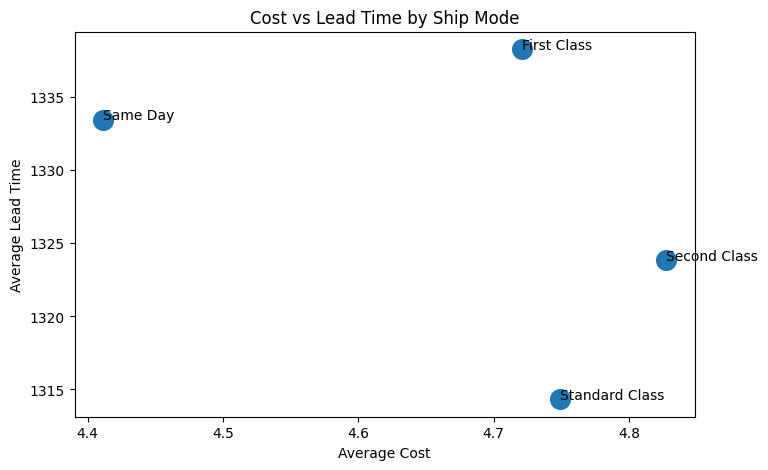

In [ ]:
# Cost-time analysis

cost_analysis = df.groupby('Ship Mode').agg({
    'Lead Time':'mean',
    'Cost':'mean'
}).reset_index()


# Plot

plt.figure(figsize=(8,5))

plt.scatter(
    cost_analysis['Cost'],
    cost_analysis['Lead Time'],
    s=200
)

# Labels

for i in range(len(cost_analysis)):
    plt.text(
        cost_analysis['Cost'][i],
        cost_analysis['Lead Time'][i],
        cost_analysis['Ship Mode'][i]
    )

plt.title("Cost vs Lead Time by Ship Mode")

plt.xlabel("Average Cost")

plt.ylabel("Average Lead Time")

plt.show()

* EFFICIENCY VS COST RATIO

In [ ]:
# Efficiency vs Cost Ratio Analysis

# Step 6: Efficiency vs Cost Ratio Analysis

# Group by Ship Mode
efficiency_vs_cost = (
    df.groupby("Ship Mode")
      .agg(
          Avg_Lead_Time=("Lead Time", "mean"),
          Avg_Cost=("Cost", "mean"),
          Total_Shipments=("Order ID", "count")
      )
      .reset_index()
)

# Calculate Efficiency per Cost Ratio
efficiency_vs_cost["Efficiency_per_Cost"] = (
    efficiency_vs_cost["Avg_Lead_Time"] /
    efficiency_vs_cost["Avg_Cost"]
)

# Round values
efficiency_vs_cost = efficiency_vs_cost.round({
    "Avg_Lead_Time": 6,
    "Avg_Cost": 6,
    "Efficiency_per_Cost": 6
})

# Sort by highest efficiency ratio
efficiency_vs_cost = efficiency_vs_cost.sort_values(
    by="Efficiency_per_Cost",
    ascending=False
)

# Display results
print("EFFICIENCY VS COST RATIO")
display(efficiency_vs_cost)


EFFICIENCY VS COST RATIO


,Ship Mode,Avg_Lead_Time,Avg_Cost,Total_Shipments,Efficiency_per_Cost
1,Same Day,1333.442413,4.411225,547,302.283936
0,First Class,1338.275840,4.721124,1548,283.465512
3,Standard Class,1314.334641,4.749328,6120,276.741156
2,Second Class,1323.845376,4.827539,1979,274.227786


* AUTOMATION LOGIC (SMART SYSTEM)

In [ ]:
# Create recommendation system

def recommend_shipping(row):
    if row['Lead Time'] > df['Lead Time'].mean():
        return "Expedited"
    else:
        return "Standard"

df['Recommended_Shipping'] = df.apply(recommend_shipping, axis=1)

# **Key Performance Indicators**

KPI 1: SHIPPING LEAD TIME

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Calculate shipping lead time

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
display(df.head())

# Explanation:
# Ship Date - Order Date → gives time difference
# .dt.days converts timedelta into number of days
# Business Insight:
# -Lower lead time = faster delivery
# -Higher lead time = delay/problem

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Units,Gross Profit,Cost,Original_Lead_Time,Lead Time,Factory,Route_State,Route_Region,Shipping_Category,Recommended_Shipping
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,2,4.22,2.28,909,909,Wicked Choccy's,Wicked Choccy's → Texas,Wicked Choccy's → Interior,Standard Shipping,Standard
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,2,4.90,2.60,909,909,Wicked Choccy's,Wicked Choccy's → Illinois,Wicked Choccy's → Interior,Standard Shipping,Standard
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3,7.47,3.00,909,909,Lot's O' Nuts,Lot's O' Nuts → Illinois,Lot's O' Nuts → Interior,Standard Shipping,Standard
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3,7.50,3.30,909,909,Lot's O' Nuts,Lot's O' Nuts → Illinois,Lot's O' Nuts → Interior,Standard Shipping,Standard
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,3,7.35,3.90,912,912,Wicked Choccy's,Wicked Choccy's → Pennsylvania,Wicked Choccy's → Atlantic,Standard Shipping,Standard


KPI 2: AVERAGE LEAD TIME

In [ ]:
# Average Lead Time=∑Lead Time​/Total Shipments
# Calculate average lead time per route

avg_lead_time = df.groupby('Route_State').agg(

    Average_Lead_Time=('Lead Time', 'mean')

).reset_index()

print(avg_lead_time)

# Explanation:
# groupby('Route_State')→ groups data route-wise
# mean→ calculates average delivery duration

# Business Insight
# Helps identify:Fast routes, Slow routes

                          Route_State  Average_Lead_Time
0             Lot's O' Nuts → Alabama        1295.205882
1             Lot's O' Nuts → Alberta        1273.875000
2             Lot's O' Nuts → Arizona        1306.198198
3            Lot's O' Nuts → Arkansas        1285.354839
4    Lot's O' Nuts → British Columbia        1273.777778
..                                ...                ...
191         Wicked Choccy's → Vermont        1418.600000
192        Wicked Choccy's → Virginia        1238.877358
193      Wicked Choccy's → Washington        1375.723982
194   Wicked Choccy's → West Virginia        1639.000000
195       Wicked Choccy's → Wisconsin        1312.234043

[196 rows x 2 columns]


KPI 3: ROUTE VOLUME

In [ ]:
# Route Volume=Count(Order ID)
# Count shipments per route

route_volume = df.groupby('Route_State').agg(

    Route_Volume=('Order ID', 'count')

).reset_index()

print(route_volume)
# Explanation: count()→ counts total orders
# Business Insight:

# High volume routes: * More operational importance , * Bigger business impact

                          Route_State  Route_Volume
0             Lot's O' Nuts → Alabama            34
1             Lot's O' Nuts → Alberta            16
2             Lot's O' Nuts → Arizona           111
3            Lot's O' Nuts → Arkansas            31
4    Lot's O' Nuts → British Columbia            18
..                                ...           ...
191         Wicked Choccy's → Vermont             5
192        Wicked Choccy's → Virginia           106
193      Wicked Choccy's → Washington           221
194   Wicked Choccy's → West Virginia             2
195       Wicked Choccy's → Wisconsin            47

[196 rows x 2 columns]


KPI 4: DELAY FREQUENCY

In [ ]:
# Delay Frequency=(Delayed Shipments/Total Shipments)​×100
# Define delay threshold

threshold = df['Lead Time'].mean()

# Create delayed shipment flag

df['Delayed'] = df['Lead Time'] > threshold

# Calculate delay frequency per route

delay_frequency = df.groupby('Route_State').agg(

    Delay_Frequency=('Delayed', 'mean')

).reset_index()

# Convert into percentage

delay_frequency['Delay_Frequency'] = (
    delay_frequency['Delay_Frequency'] * 100
)

print(delay_frequency)

# Explanation: Boolean values: True = 1, False = 0
# Mean of boolean column:→ gives percentage of delayed shipments

                          Route_State  Delay_Frequency
0             Lot's O' Nuts → Alabama        26.470588
1             Lot's O' Nuts → Alberta        25.000000
2             Lot's O' Nuts → Arizona        28.828829
3            Lot's O' Nuts → Arkansas        29.032258
4    Lot's O' Nuts → British Columbia        33.333333
..                                ...              ...
191         Wicked Choccy's → Vermont        40.000000
192        Wicked Choccy's → Virginia        19.811321
193      Wicked Choccy's → Washington        45.248869
194   Wicked Choccy's → West Virginia       100.000000
195       Wicked Choccy's → Wisconsin        21.276596

[196 rows x 2 columns]


KPI 5: ROUTE EFFICIENCY SCORE

In [ ]:
# Route Efficiency Score= 1/Average Lead Time

# Create route efficiency table

route_efficiency = df.groupby('Route_State').agg(

    Avg_Lead_Time=('Lead Time', 'mean')

).reset_index()

# Calculate efficiency score

route_efficiency['Efficiency_Score'] = (
    1 / route_efficiency['Avg_Lead_Time']
)

print(route_efficiency)

# Explanation: Smaller lead time → larger efficiency score
# Converts: "lower is better" → into "higher is better"

# Business Insight:
# Efficiency Score High means Efficient route
# Efficiency Score low means poor route



                          Route_State  Avg_Lead_Time  Efficiency_Score
0             Lot's O' Nuts → Alabama    1295.205882          0.000772
1             Lot's O' Nuts → Alberta    1273.875000          0.000785
2             Lot's O' Nuts → Arizona    1306.198198          0.000766
3            Lot's O' Nuts → Arkansas    1285.354839          0.000778
4    Lot's O' Nuts → British Columbia    1273.777778          0.000785
..                                ...            ...               ...
191         Wicked Choccy's → Vermont    1418.600000          0.000705
192        Wicked Choccy's → Virginia    1238.877358          0.000807
193      Wicked Choccy's → Washington    1375.723982          0.000727
194   Wicked Choccy's → West Virginia    1639.000000          0.000610
195       Wicked Choccy's → Wisconsin    1312.234043          0.000762

[196 rows x 3 columns]


In [ ]:
# Save the cleaned dataframe
df.to_csv("Nassau_Candy_Cleaned.csv", index=False)